# Chatbot With MCP Server

In [1]:
%pip install langchain-mcp-adapters mcp pywin32 -Uqqq

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['PINECONE_API_KEY'] = os.getenv('PINECONE_API_KEY')
os.environ['COHERE_API_KEY'] = os.getenv('COHERE_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [3]:
# Tavily Search 도구 생성 및 검색
from langchain_tavily import TavilySearch

tavilly_tool = TavilySearch(max_results=3)
tavilly_tool.invoke("랭그래프의ㅣ 노드와 엣지가 뭐야?")

{'query': '랭그래프의ㅣ 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다',
   'content': '## 1. 노드 (Node)\n\n### 1.1.  노드 개념\n\n노드는 데이터를 입력받아 처리한 뒤 결과를 반환하는 실행 단위다.  \nLangGraph에서는 파이썬 함수나 Runnable 객체, 클래스 형태로 정의할 수 있다.\n\n 특징\n  + 하나의 노드는 하나의 역할에 집중하는 것이 좋다.\n  + 입력과 출력은 State를 기반으로 한다.\n  + 노드의 이름은 고유해야 한다.\n\n### 1.2. 노드 만드는 법 기본\n\n#### 1.2.1. 함수로 노드 만들기\n\n입력\n\n state 를 입력으로 받음\n\nreturn 규칙\n\n 반드시 dict 형식으로 반환해야 하며, key는 State에서 정의한 필드와 일치해야 함.\n LangGraph는 이 dict를 기존 state에 \\\\병합(merge)\\\\한다.\n 필요한 필드만 반환해도 되고, 나머지는 이전 state 값이 유지된다.\n\ngraph에 노드 추가하기 [...] ### 2.1. 엣지 개념\n\n엣지는 노드와 노드를 연결하는 경로다. 데이터가 한 노드에서 다음 노드로 흘러가는 길이라고 보면 된다.  \n   \n특징\n\n 엣지는 시작 노드와 도착 노드를 지정해야 한다.\n 조건부 엣지를 설정해 흐름을 분기시킬 수 있다.\n 한 노드에서 여러 노드로 데이터를 보낼 수도 있다.\n\n### 2.2. 엣지 만드는 방법\n\n#### 2.2.1. 일반 edge\

### MCP Server 연동
- `http` 원격지의 MCP Server를 web 방식 호출
- `stdio` MCP Client system에서 MCP Server구동하는 경우

In [ ]:
# MultiServerMCPClient로 MCP서버 2개 연결 후 도구 목록 조회
from langchain_mcp_adapters.client import MultiServerMCPClient

CONTEXT7_API_KEY = os.getenv('CONTEXT7_API_KEY')

# MCP 서버설정 클라이언트
mcp_client = MultiServerMCPClient({
    # Langchain Cocs MCP 서버
    "docs-langchain": {
        "url": "https://docs.langchain.com/mcp",    # 엔드포인트
        "transport": "http"
    },
    # Context7 MCP 서버
    "context7": {
        "url": "https://mcp.context7.com/mcp",      # 엔드포인트
        "headers": {                                # 인증정보를 담은 헤더
            "CONTEXT7_API_KEY": CONTEXT7_API_KEY
        },
        "transport": "http"
    }
})

mcp_tools = await mcp_client.get_tools()
mcp_tools

[StructuredTool(name='search_docs_by_lang_chain', description='Search across the Docs by LangChain knowledge base to find relevant information, code examples, API references, and guides. Use this tool when you need to answer questions about Docs by LangChain, find specific documentation, understand how features work, or locate implementation details. The search returns contextual content with titles and direct links to the documentation pages. If you need the full content of a specific page, use the query_docs_filesystem tool to `head` or `cat` the page path (append `.mdx` to the path returned from search — e.g. `head -200 /api-reference/create-customer.mdx`).', args_schema={'type': 'object', 'properties': {'query': {'type': 'string', 'description': 'Search query'}}, 'required': ['query'], 'additionalProperties': False}, metadata={'title': None, 'readOnlyHint': True, 'destructiveHint': False, 'idempotentHint': True, 'openWorldHint': False}, handle_tool_error=<function _handle_mcp_tool_

In [6]:
from typing import TypedDict, Annotated, List     # 타입 힌트 도구
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch

tavilly_tool = TavilySearch(max_results=3)

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages]  # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.6-luna')
tools = [tavilly_tool] + mcp_tools
llm_with_tools = llm.bind_tools(tools)

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]}  # add_messages 규칙에 의해 기존 messages에 응답이 누적됨

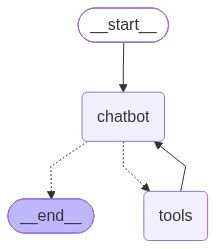

In [8]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)     # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)


builder.add_edge(START, 'chatbot')  # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile()  # 설계된 워크프로우를 실행 가능한 그래프로 컴파일

graph  # 그래프 객체

In [10]:
from pprint import pprint

user_query = '최근 삼성전자와 하이닉스 주가는 어떻게 돼?'

state = {'messages': [('human', user_query)]}    # HumanMessage 객체 내 메세지 구현 

response = graph.invoke(state)      # 그래프 실행 (START -> CHATBOT -> (tool 루프)or END)

pprint(response)
print('='*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 삼성전자와 하이닉스 주가는 어떻게 돼?', additional_kwargs={}, response_metadata={}, id='df165f81-ef7b-4468-8c98-9f3a33e9b999'),
              AIMessage(content='현재 실시간 시세를 조회할 수 없어 **2026년 9월 3일 기준 삼성전자·SK하이닉스의 정확한 주가와 최근 등락률은 확인해 드리기 어렵습니다.** 숫자를 임의로 제시하진 않겠습니다.\n\n- **삼성전자**: 코스피 `005930`\n- **SK하이닉스**: 코스피 `000660`\n\n네이버증권, 한국거래소(KRX), 증권사 앱에서 종목코드를 검색하면 현재가·전일 대비·최근 1개월 추이를 확인할 수 있습니다.  \n최근 흐름을 비교하려면 **현재가, 1주·1개월 수익률, 외국인 순매수**를 함께 보시면 됩니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 330, 'prompt_tokens': 20, 'total_tokens': 350, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 154, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': 0, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.6-luna', 'system_fingerprint': None, 

In [11]:
user_query = 'langchain 최신 버전에서 새롭게 추가된 부분은?'

state = {'messages': [('human', user_query)]}    # HumanMessage 객체 내 메세지 구현 

response = graph.invoke(state)      # 그래프 실행 (START -> CHATBOT -> (tool 루프)or END)

pprint(response)
print('='*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='langchain 최신 버전에서 새롭게 추가된 부분은?', additional_kwargs={}, response_metadata={}, id='74542df8-5c0e-4832-94b3-d41ffc9feb70'),
              AIMessage(content='정확한 “최신 버전”의 변경점은 Python/JS 및 세부 버전에 따라 다르지만, 최근 LangChain의 큰 변화는 **LangChain 1.0 계열로의 전환**입니다. 핵심은 다음과 같습니다.\n\n## 주요 추가·변경 사항\n\n### 1. 새로운 Agent API: `create_agent`\n\n기존의 다음 API보다:\n\n```python\nfrom langchain.agents import initialize_agent, AgentType\n```\n\n최근에는 다음 방식을 권장합니다.\n\n```python\nfrom langchain.agents import create_agent\n\nagent = create_agent(\n    model="openai:gpt-4.1-mini",\n    tools=[...],\n    system_prompt="도구를 활용해 답변하세요."\n)\n\nresult = agent.invoke({\n    "messages": [\n        {"role": "user", "content": "서울의 날씨를 알려줘"}\n    ]\n})\n```\n\n`create_agent`는 내부적으로 **LangGraph 기반 실행 구조**를 사용합니다.\n\n---\n\n### 2. LangGraph와의 통합 강화\n\nAgent 실행이 단순한 일회성 호출에서 다음 기능을 지원하는 방향으로 발전했습니다.\n\n- 상태 기반 워크플로\n- 반복 실행 및 조건 분기\n- 체크포인트와 대화 상태 저장\n- 장시간 실행 작업\n- Human-in-the-loop\n- 중단 후 재개\n-

In [12]:
user_query = '웹 프론트엔드 "개발시 필요한 라이브러리가 뭐야?'

state = {'messages': [('human', user_query)]}    # HumanMessage 객체 내 메세지 구현 

response = graph.invoke(state)      # 그래프 실행 (START -> CHATBOT -> (tool 루프)or END)

pprint(response)
print('='*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='웹 프론트엔드 "개발시 필요한 라이브러리가 뭐야?', additional_kwargs={}, response_metadata={}, id='6834cc27-4267-45dd-b30c-f3e5830f9e12'),
              AIMessage(content='웹 프론트엔드 개발에 필요한 라이브러리는 프로젝트 규모와 기술 스택에 따라 다릅니다. 모두 사용할 필요는 없고, 기본 기술부터 익힌 뒤 필요한 것만 선택하면 됩니다.\n\n## 1. 기본 기술\n\n라이브러리보다 먼저 익혀야 합니다.\n\n- **HTML**: 페이지 구조\n- **CSS**: 디자인과 레이아웃\n- **JavaScript / TypeScript**: 동작과 로직\n- **Git**: 버전 관리\n- **HTTP, REST API, JSON**: 서버와 데이터 통신\n\n## 2. 프론트엔드 프레임워크\n\n보통 하나를 선택합니다.\n\n- **React**: 가장 널리 사용되는 생태계\n- **Vue**: 배우기 쉽고 구조가 직관적\n- **Angular**: 기업용 대규모 프로젝트에 적합\n- **Svelte**: 간결하고 빠른 개발 경험\n- **Next.js**: React 기반의 SSR, 라우팅, 풀스택 기능 제공\n- **Nuxt**: Vue 기반 프레임워크\n\n입문자라면 보통 다음 중 하나를 추천합니다.\n\n```text\nReact + TypeScript\nVue + TypeScript\n```\n\n## 3. UI 및 CSS 라이브러리\n\n직접 CSS를 작성하는 대신 사용할 수 있습니다.\n\n- **Tailwind CSS**: 유틸리티 클래스 방식\n- **Bootstrap**: 빠르게 기본 UI 구성\n- **Material UI**: React용 Material Design 컴포넌트\n- **Ant Design**: 관리자 페이지와 기업용 UI\n- **shadcn/ui**: Tailwin